# 02 Benchmark Model

This notebook analyzes previously trained YOLO benchmark models for Gram-stained bacteria detection.

It does not retrain any model. Instead, it loads saved training result files, extracts comparable metrics, visualizes performance differences, and supports best-model selection for final development.

## Benchmark Objective

The goal of this benchmark is to compare multiple YOLO-based object detection models and identify the most suitable architecture for this project.

Evaluated models:

- YOLOv8n
- YOLOv8s
- YOLOv8m
- YOLOv11n
- YOLOv11s
- YOLOv11m

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "benchmark result"
SUMMARY_OUTPUT_PATH = RESULTS_DIR / "benchmark_metrics.csv"

MODEL_FILES = {
    "YOLOv8n": "yolov8n_results.csv",
    "YOLOv8s": "yolov8s_results.csv",
    "YOLOv8m": "yolov8m_results.csv",
    "YOLOv11n": "yolov11n_results.csv",
    "YOLOv11s": "yolov11s_results.csv",
    "YOLOv11m": "yolov11m_results.csv",
}

RESULTS_DIR

WindowsPath('d:/Senior/gram-stain-bacteria-detection/benchmark result')

## Load Benchmark Results

In [2]:
def load_result_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df.columns = [col.strip() for col in df.columns]
    return df


results = {}
for model_name, filename in MODEL_FILES.items():
    csv_path = RESULTS_DIR / filename
    results[model_name] = load_result_csv(csv_path)

loaded_summary = pd.DataFrame(
    {
        "Model": list(results.keys()),
        "Rows": [len(df) for df in results.values()],
        "Columns": [len(df.columns) for df in results.values()],
        "File": [MODEL_FILES[name] for name in results.keys()],
    }
)
loaded_summary

,Model,Rows,Columns,File
0,YOLOv8n,50,15,yolov8n_results.csv
1,YOLOv8s,50,15,yolov8s_results.csv
2,YOLOv8m,50,15,yolov8m_results.csv
3,YOLOv11n,50,15,yolov11n_results.csv
4,YOLOv11s,50,15,yolov11s_results.csv
5,YOLOv11m,50,15,yolov11m_results.csv


In [3]:
results["YOLOv8m"].head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,10.2075,3.4795,4.0292,1.4582,0.2233,0.2153,0.1572,0.0755,2.0584,1.9945,0.9901,0.0001,0.0001,0.0001
1,2,16.5690,2.5668,1.8550,1.0617,0.2932,0.4314,0.3294,0.1713,1.8337,3.1753,0.9077,0.0002,0.0002,0.0002
2,3,27.3376,2.2564,1.5044,0.9831,0.4317,0.5532,0.4479,0.2251,1.8993,2.0724,0.8953,0.0003,0.0003,0.0003
3,4,38.1813,2.1140,1.3346,0.9464,0.4903,0.5753,0.5053,0.2724,1.7950,2.3979,0.8845,0.0004,0.0004,0.0004
4,5,44.8194,2.0729,1.2951,0.9316,0.3971,0.6461,0.4428,0.2190,1.7938,3.0329,0.8866,0.0005,0.0005,0.0005


## Extract Final or Best Epoch Metrics

Selection rule used in this notebook:

- Select the epoch with the highest `mAP@50-95`
- Use that epoch as the representative benchmark result for each model

In [4]:
COLUMN_MAP = {
    "epoch": "epoch",
    "time": "time",
    "metrics/precision(B)": "precision",
    "metrics/recall(B)": "recall",
    "metrics/mAP50(B)": "map50",
    "metrics/mAP50-95(B)": "map50_95",
    "train/box_loss": "train_box_loss",
    "train/cls_loss": "train_cls_loss",
    "train/dfl_loss": "train_dfl_loss",
    "val/box_loss": "val_box_loss",
    "val/cls_loss": "val_cls_loss",
    "val/dfl_loss": "val_dfl_loss",
}


def standardize_result_df(df: pd.DataFrame) -> pd.DataFrame:
    renamed = df.rename(columns=COLUMN_MAP).copy()
    if "epoch" in renamed.columns:
        renamed["epoch"] = renamed["epoch"].astype(int)
    return renamed


results_std = {model: standardize_result_df(df) for model, df in results.items()}
results_std["YOLOv8m"].head()

,epoch,time,train_box_loss,train_cls_loss,train_dfl_loss,precision,recall,map50,map50_95,val_box_loss,val_cls_loss,val_dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,10.2075,3.4795,4.0292,1.4582,0.2233,0.2153,0.1572,0.0755,2.0584,1.9945,0.9901,0.0001,0.0001,0.0001
1,2,16.5690,2.5668,1.8550,1.0617,0.2932,0.4314,0.3294,0.1713,1.8337,3.1753,0.9077,0.0002,0.0002,0.0002
2,3,27.3376,2.2564,1.5044,0.9831,0.4317,0.5532,0.4479,0.2251,1.8993,2.0724,0.8953,0.0003,0.0003,0.0003
3,4,38.1813,2.1140,1.3346,0.9464,0.4903,0.5753,0.5053,0.2724,1.7950,2.3979,0.8845,0.0004,0.0004,0.0004
4,5,44.8194,2.0729,1.2951,0.9316,0.3971,0.6461,0.4428,0.2190,1.7938,3.0329,0.8866,0.0005,0.0005,0.0005


In [5]:
def compute_f1(precision: float, recall: float) -> float:
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def extract_best_epoch_metrics(model_name: str, df: pd.DataFrame) -> dict:
    best_idx = df["map50_95"].idxmax()
    row = df.loc[best_idx]

    return {
        "Model": model_name,
        "Best Epoch": int(row["epoch"]),
        "mAP@50": row["map50"],
        "mAP@50-95": row["map50_95"],
        "Precision": row["precision"],
        "Recall": row["recall"],
        "F1": compute_f1(row["precision"], row["recall"]),
        "Train Box Loss": row["train_box_loss"],
        "Train Cls Loss": row["train_cls_loss"],
        "Train DFL Loss": row["train_dfl_loss"],
        "Val Box Loss": row["val_box_loss"],
        "Val Cls Loss": row["val_cls_loss"],
        "Val DFL Loss": row["val_dfl_loss"],
        "Best Epoch Time": row["time"],
    }


benchmark_summary = pd.DataFrame(
    [extract_best_epoch_metrics(model, df) for model, df in results_std.items()]
).sort_values("mAP@50-95", ascending=False)

benchmark_summary = benchmark_summary.round(4)
benchmark_summary

,Model,Best Epoch,mAP@50,mAP@50-95,Precision,Recall,F1,Train Box Loss,Train Cls Loss,Train DFL Loss,Val Box Loss,Val Cls Loss,Val DFL Loss,Best Epoch Time
5,YOLOv11m,38,0.8411,0.5172,0.7567,0.8122,0.7835,1.5146,0.8244,0.8503,1.3436,0.7223,0.8386,285.1390
2,YOLOv8m,39,0.8355,0.5083,0.7778,0.7785,0.7781,1.6222,0.8974,0.8512,1.3767,0.7506,0.8437,273.9830
4,YOLOv11s,50,0.8290,0.4840,0.7387,0.8009,0.7686,1.5324,0.8521,0.8581,1.4495,0.7478,0.8416,221.2290
1,YOLOv8s,50,0.8147,0.4746,0.7410,0.7756,0.7579,1.5594,0.8846,0.8601,1.4554,0.7691,0.8434,202.0440
3,YOLOv11n,45,0.7527,0.4046,0.7192,0.7313,0.7252,1.8072,1.2622,0.8871,1.6744,0.9288,0.8649,187.2140
0,YOLOv8n,50,0.7430,0.3914,0.6992,0.7270,0.7128,1.8352,1.1865,0.8877,1.7281,0.9205,0.8663,167.6220


## Save Combined Benchmark Summary

In [6]:
benchmark_summary.to_csv(SUMMARY_OUTPUT_PATH, index=False)
print(f"Saved benchmark summary to: {SUMMARY_OUTPUT_PATH}")

Saved benchmark summary to: d:\Senior\gram-stain-bacteria-detection\benchmark result\benchmark_metrics.csv


In [7]:
pd.read_csv(SUMMARY_OUTPUT_PATH).head()

,Model,Best Epoch,mAP@50,mAP@50-95,Precision,Recall,F1,Train Box Loss,Train Cls Loss,Train DFL Loss,Val Box Loss,Val Cls Loss,Val DFL Loss,Best Epoch Time
0,YOLOv11m,38,0.8411,0.5172,0.7567,0.8122,0.7835,1.5146,0.8244,0.8503,1.3436,0.7223,0.8386,285.1390
1,YOLOv8m,39,0.8355,0.5083,0.7778,0.7785,0.7781,1.6222,0.8974,0.8512,1.3767,0.7506,0.8437,273.9830
2,YOLOv11s,50,0.8290,0.4840,0.7387,0.8009,0.7686,1.5324,0.8521,0.8581,1.4495,0.7478,0.8416,221.2290
3,YOLOv8s,50,0.8147,0.4746,0.7410,0.7756,0.7579,1.5594,0.8846,0.8601,1.4554,0.7691,0.8434,202.0440
4,YOLOv11n,45,0.7527,0.4046,0.7192,0.7313,0.7252,1.8072,1.2622,0.8871,1.6744,0.9288,0.8649,187.2140


## Visualize Model Comparison

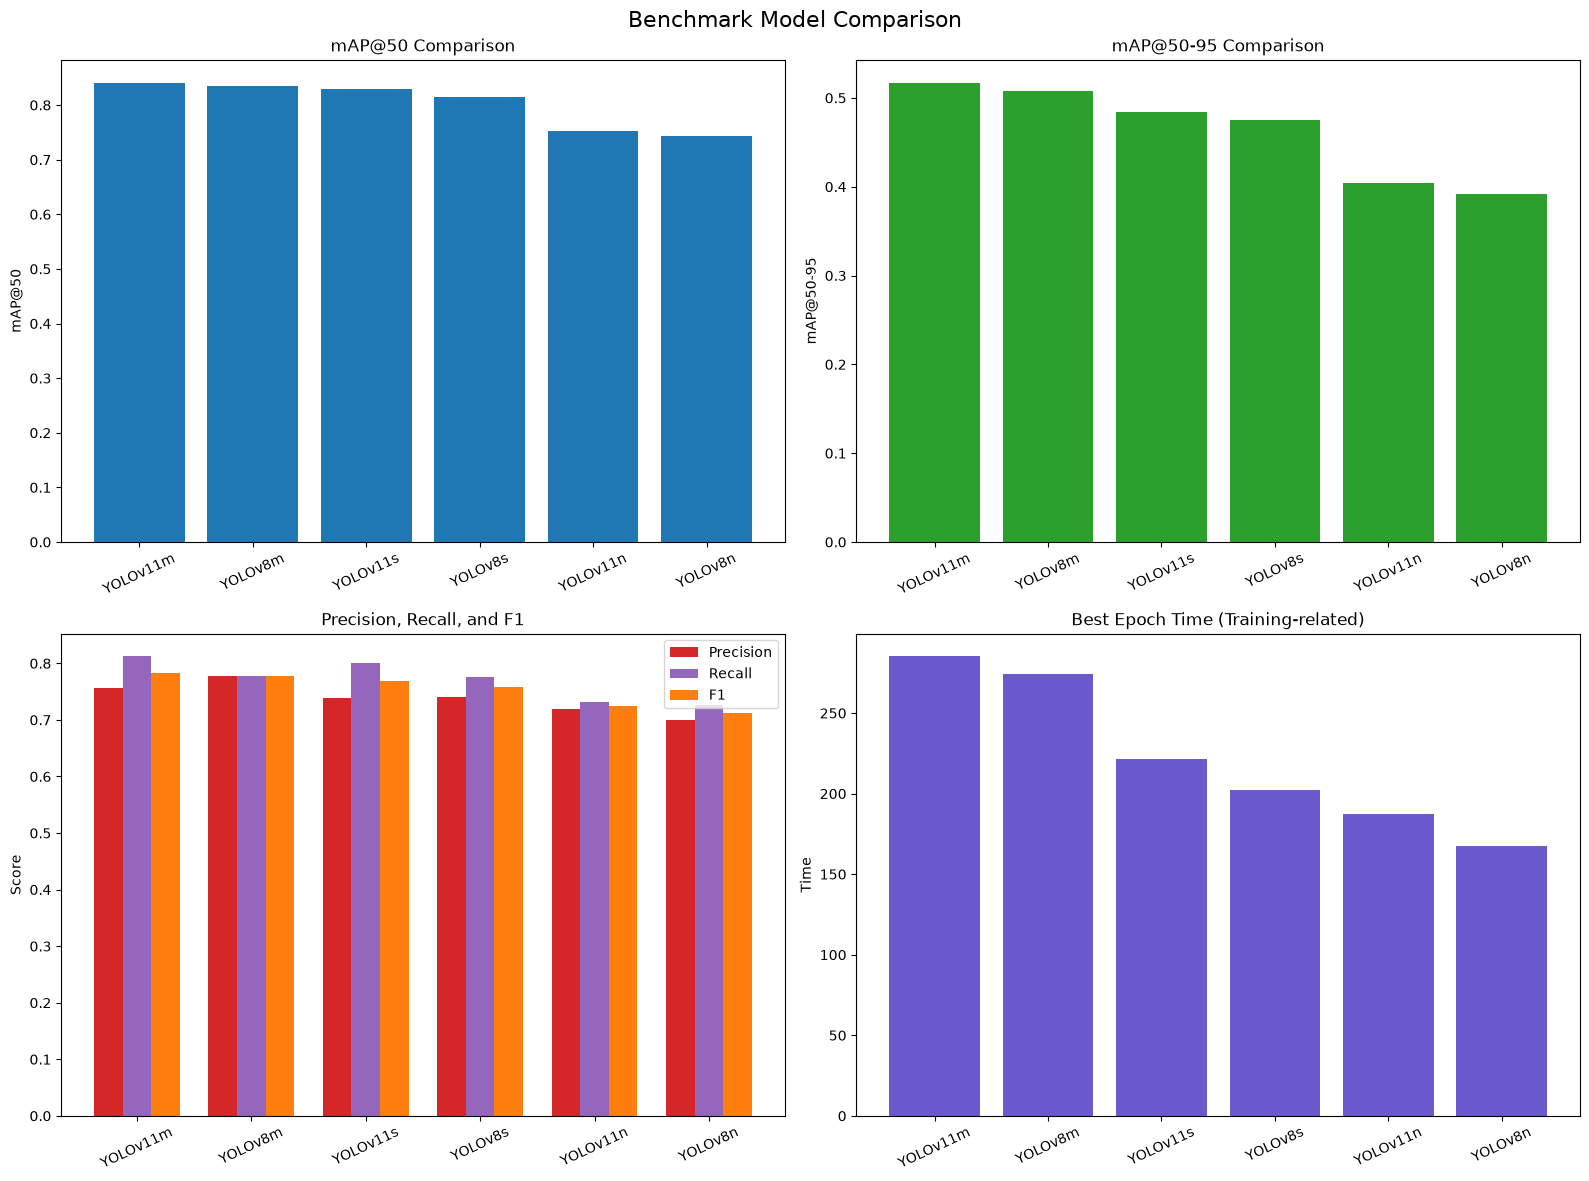

In [8]:
plot_df = benchmark_summary.sort_values("mAP@50-95", ascending=False).copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(plot_df["Model"], plot_df["mAP@50"], color="tab:blue")
axes[0, 0].set_title("mAP@50 Comparison")
axes[0, 0].set_ylabel("mAP@50")
axes[0, 0].tick_params(axis="x", rotation=25)

axes[0, 1].bar(plot_df["Model"], plot_df["mAP@50-95"], color="tab:green")
axes[0, 1].set_title("mAP@50-95 Comparison")
axes[0, 1].set_ylabel("mAP@50-95")
axes[0, 1].tick_params(axis="x", rotation=25)

x = np.arange(len(plot_df))
width = 0.25
axes[1, 0].bar(x - width, plot_df["Precision"], width=width, label="Precision", color="tab:red")
axes[1, 0].bar(x, plot_df["Recall"], width=width, label="Recall", color="tab:purple")
axes[1, 0].bar(x + width, plot_df["F1"], width=width, label="F1", color="tab:orange")
axes[1, 0].set_title("Precision, Recall, and F1")
axes[1, 0].set_ylabel("Score")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(plot_df["Model"], rotation=25)
axes[1, 0].legend()

axes[1, 1].bar(plot_df["Model"], plot_df["Best Epoch Time"], color="slateblue")
axes[1, 1].set_title("Best Epoch Time (Training-related)")
axes[1, 1].set_ylabel("Time")
axes[1, 1].tick_params(axis="x", rotation=25)

fig.suptitle("Benchmark Model Comparison", fontsize=16)
fig.tight_layout()
plt.show()

## Training Curve Analysis

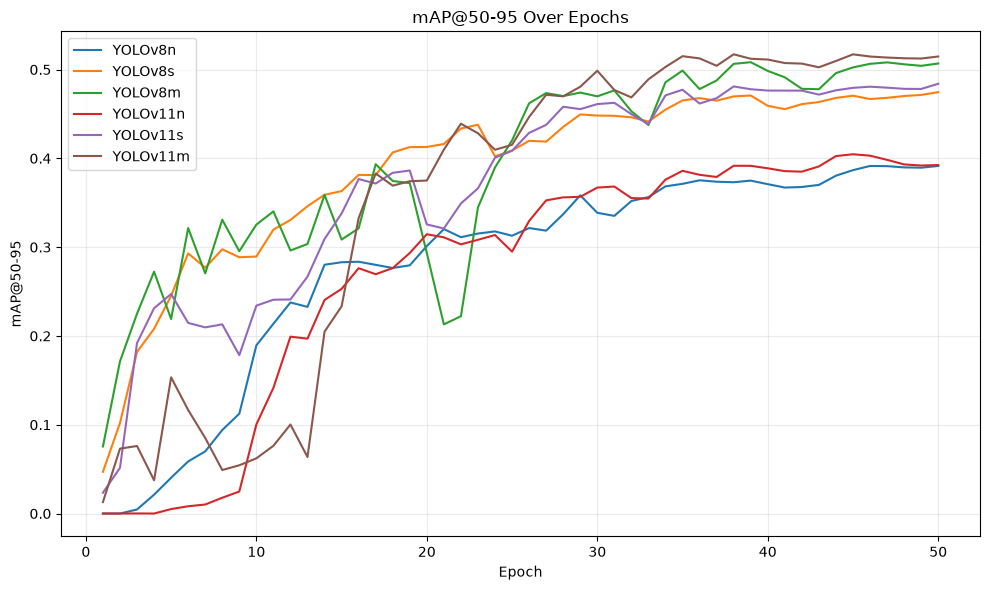

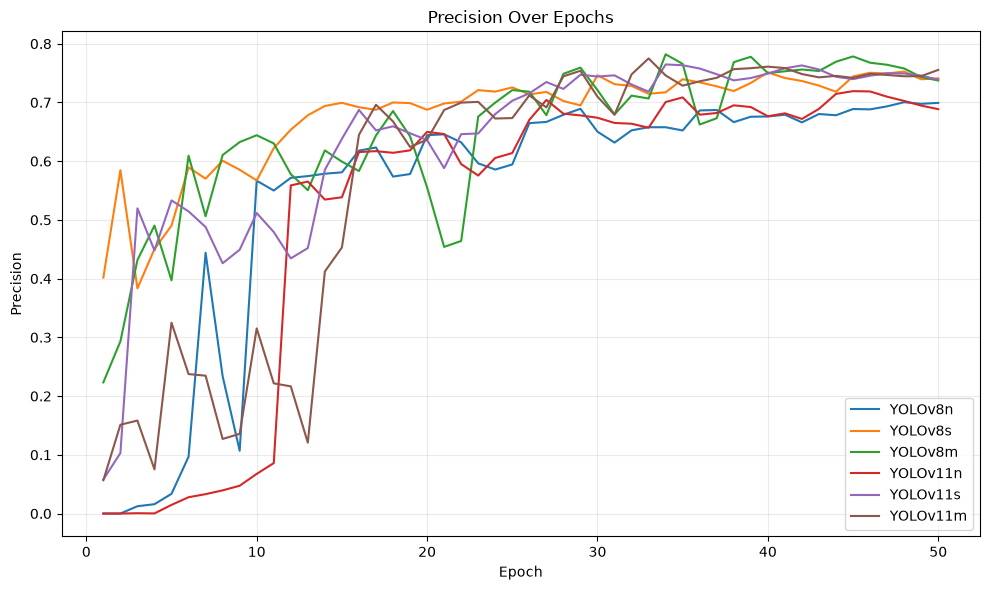

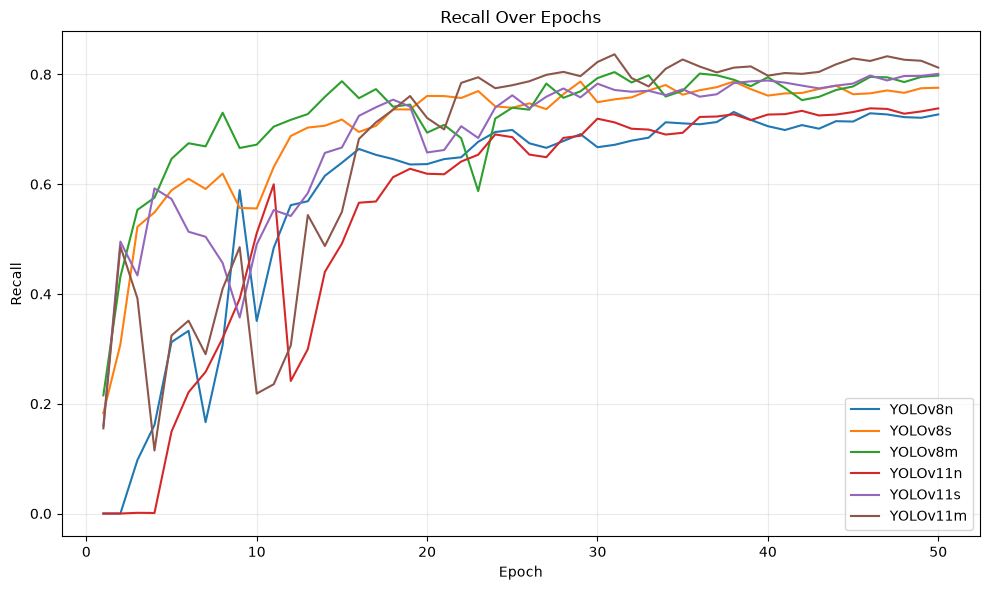

In [9]:
def plot_metric_curves(results_dict: dict[str, pd.DataFrame], metric: str, title: str, ylabel: str):
    plt.figure(figsize=(10, 6))
    for model_name, df in results_dict.items():
        plt.plot(df["epoch"], df[metric], label=model_name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_metric_curves(results_std, metric="map50_95", title="mAP@50-95 Over Epochs", ylabel="mAP@50-95")
plot_metric_curves(results_std, metric="precision", title="Precision Over Epochs", ylabel="Precision")
plot_metric_curves(results_std, metric="recall", title="Recall Over Epochs", ylabel="Recall")

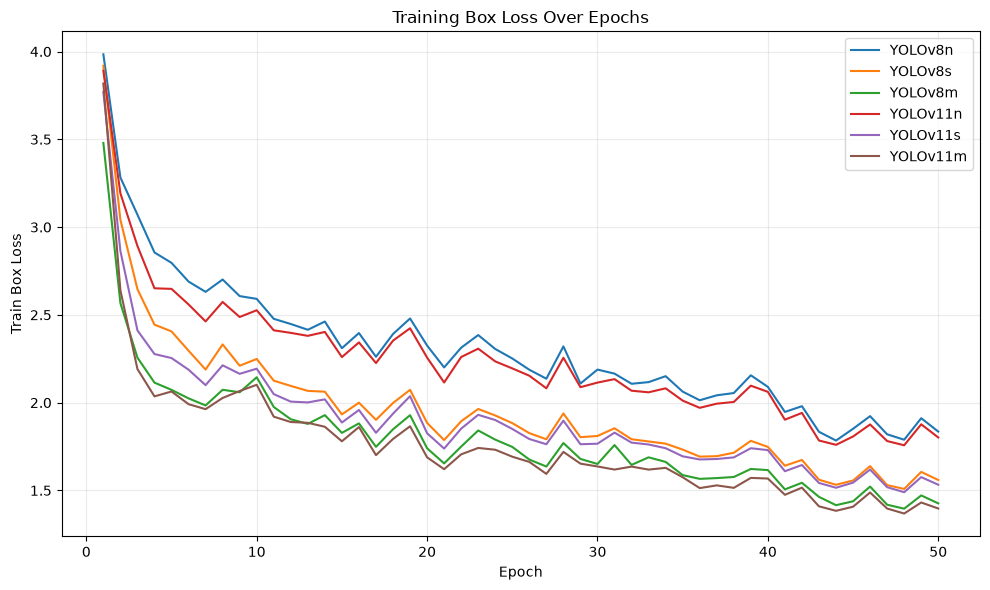

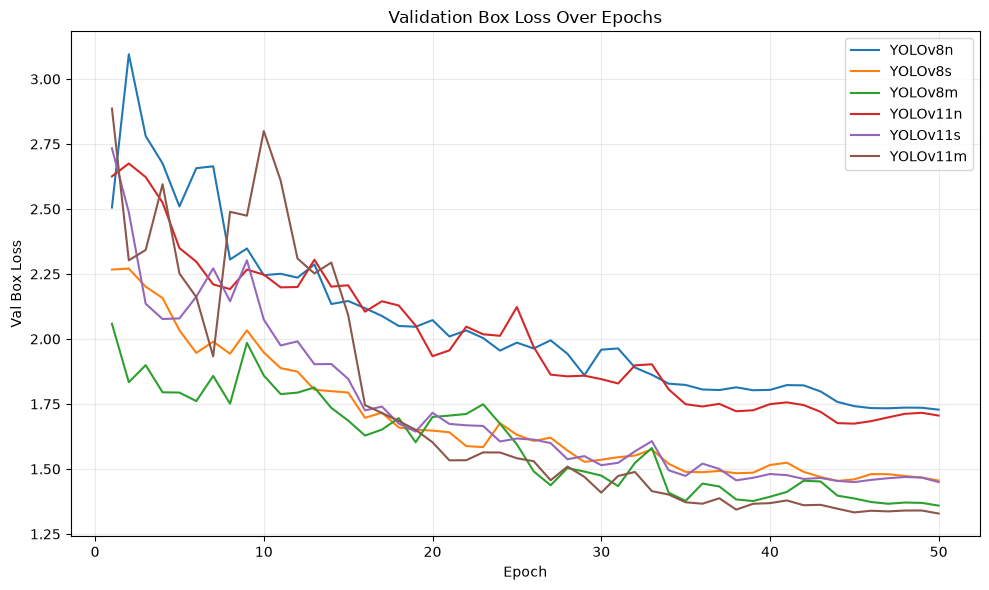

In [10]:
plot_metric_curves(results_std, metric="train_box_loss", title="Training Box Loss Over Epochs", ylabel="Train Box Loss")
plot_metric_curves(results_std, metric="val_box_loss", title="Validation Box Loss Over Epochs", ylabel="Val Box Loss")

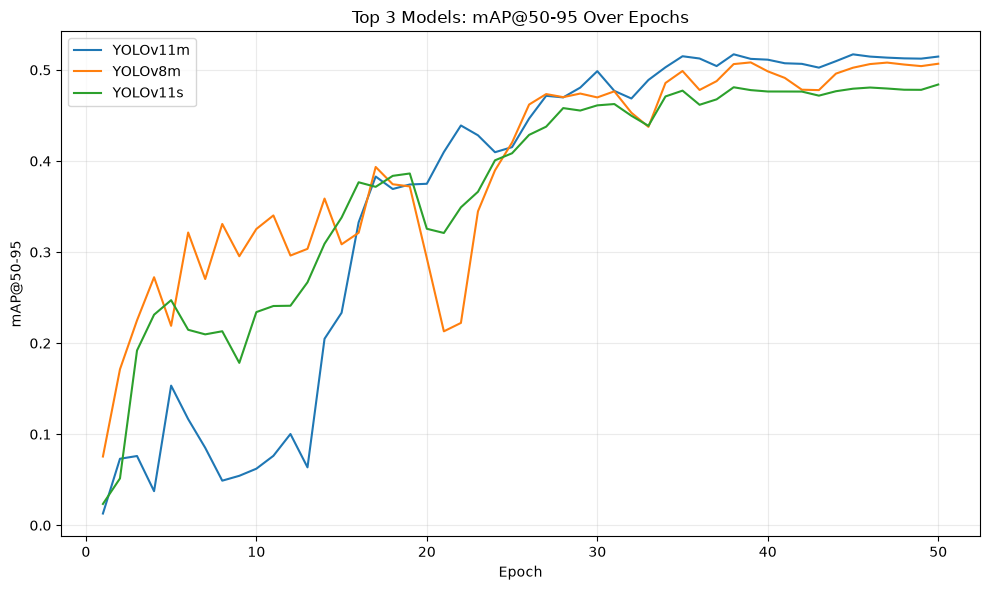

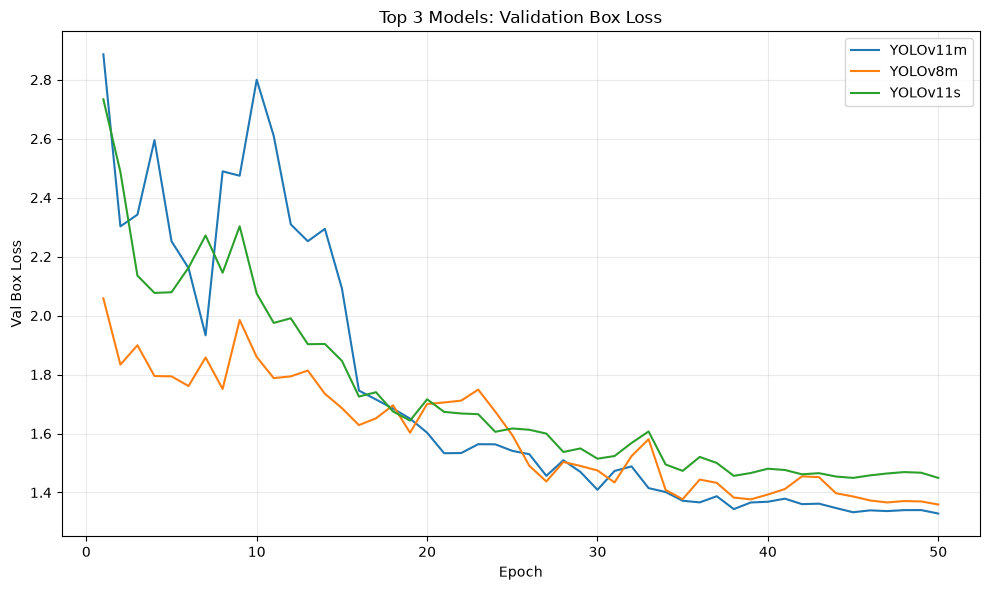

In [11]:
top_models = benchmark_summary.sort_values("mAP@50-95", ascending=False)["Model"].head(3).tolist()
top_results = {model: results_std[model] for model in top_models}

plot_metric_curves(top_results, metric="map50_95", title="Top 3 Models: mAP@50-95 Over Epochs", ylabel="mAP@50-95")
plot_metric_curves(top_results, metric="val_box_loss", title="Top 3 Models: Validation Box Loss", ylabel="Val Box Loss")

## Best Model Selection

In [12]:
selected_model_row = benchmark_summary.sort_values("mAP@50-95", ascending=False).iloc[0]

selection_summary = pd.DataFrame(
    [
        {
            "Selected Model": selected_model_row["Model"],
            "Reason": "Highest mAP@50-95 among benchmarked models",
            "mAP@50": selected_model_row["mAP@50"],
            "mAP@50-95": selected_model_row["mAP@50-95"],
            "Precision": selected_model_row["Precision"],
            "Recall": selected_model_row["Recall"],
            "F1": selected_model_row["F1"],
        }
    ]
)

selection_summary

,Selected Model,Reason,mAP@50,mAP@50-95,Precision,Recall,F1
0,YOLOv11m,Highest mAP@50-95 among benchmarked models,0.8411,0.5172,0.7567,0.8122,0.7835


Suggested interpretation:

- Start with the model that achieves the best `mAP@50-95`
- Check whether its precision and recall remain balanced
- If deployment constraints become important later, compare this selected model against lighter alternatives using inference benchmarks and model size

## 8. Benchmark Discussion

In [13]:
discussion_table = benchmark_summary[["Model", "Best Epoch", "mAP@50", "mAP@50-95", "Precision", "Recall", "F1"]].copy()
discussion_table

,Model,Best Epoch,mAP@50,mAP@50-95,Precision,Recall,F1
5,YOLOv11m,38,0.8411,0.5172,0.7567,0.8122,0.7835
2,YOLOv8m,39,0.8355,0.5083,0.7778,0.7785,0.7781
4,YOLOv11s,50,0.8290,0.4840,0.7387,0.8009,0.7686
1,YOLOv8s,50,0.8147,0.4746,0.7410,0.7756,0.7579
3,YOLOv11n,45,0.7527,0.4046,0.7192,0.7313,0.7252
0,YOLOv8n,50,0.7430,0.3914,0.6992,0.7270,0.7128
